# Understanding US Flight Delays: What Makes Flights Late?


## An Analysis of 2025 Airline On-Time Performance Data

## by Luis Feliu


## Investigation Overview

This presentation communicates the key findings from an exploratory analysis of **7,001,619 US domestic scheduled flights in 2025**. The data comes from the Bureau of Transportation Statistics (BTS) Reporting Carrier On-Time Performance database. The guiding theme is: **which operational, timing, seasonal, and geographic patterns explain whether flights arrive late or recover time?**

**Five guiding questions and key insights:**

1. **Do flights recover after departure?** Completed flights usually make up delay minutes after departure; the median arrival-minus-departure delay is -7 minutes
2. **Which delay causes matter most?** Late-arriving aircraft and carrier-controlled operational delays are the largest attributed causes, with airspace/airport-flow delays also substantial
3. **When is delay risk highest?** Sunday evening is the highest-risk timing window
4. **How does risk change by season?** June/July lead the year, with a separate December spike
5. **Where do recovery patterns differ?** Origin states and territories differ, but state/territory aggregation is coarse

Together, these insights show that delay risk is shaped most by operational reliability, airspace constraints, and schedule timing, while flights often recover some time between departure and arrival.


## Dataset Overview

- **Source:** Bureau of Transportation Statistics (BTS) Reporting Carrier On-Time Performance Data
- **Coverage:** US domestic scheduled flights in 2025
- **Scope:** 7,001,619 scheduled flights; 6,879,484 completed flights used for delay analysis
- **Local data:** monthly source ZIP files in `data/raw/`; optional ignored cache in `data/processed/combined_2025.csv`

The analysis focuses on whether flights arrive late, what causes attributed delay minutes, and when flights recover time after departure. If the saved output reports the processed cache as the source, that reflects the local cache path used for faster reruns; a clean checkout without the cache loads from the committed monthly ZIP files.


## Analysis Fields

| Field group | Used for |
|---|---|
| `DepDelay`, `ArrDelay`, `DelayDelta` | Schedule deviation and recovery |
| `DepDel15`, `ArrDel15` | Official 15+ minute delay rates |
| `CarrierDelay`, `WeatherDelay`, `NASDelay`, `SecurityDelay`, `LateAircraftDelay` | Attributed delay causes |
| `Month`, `DayOfWeek`, `CRSDepTime`, `OriginState` | Seasonal, timing, and geographic patterns |

**Note:** Cancelled and diverted flights are excluded from delay analysis because they do not have comparable completed-flight arrival outcomes. Blank delay-cause fields are treated as 0 minutes.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from zipfile import ZipFile

# Plotting style polished for presentation
sns.set_style('whitegrid')
sns.set_context('notebook', font_scale=1.0)
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['font.size'] = 12

# Suppress warnings
import warnings
warnings.simplefilter('ignore')


In [2]:
cols = ['Year','Month','DayofMonth','DayOfWeek','FlightDate',
    'IATA_CODE_Reporting_Airline','Origin','OriginCityName','OriginState',
    'Dest','DestCityName','DestState',
    'CRSDepTime','DepTime','DepDelay','DepDelayMinutes','DepDel15',
    'DepartureDelayGroups','DepTimeBlk',
    'CRSArrTime','ArrTime','ArrDelay','ArrDelayMinutes','ArrDel15',
    'ArrivalDelayGroups','ArrTimeBlk',
    'Cancelled','CancellationCode','Diverted',
    'ActualElapsedTime','AirTime','Flights','Distance','DistanceGroup',
    'CarrierDelay','WeatherDelay','NASDelay','SecurityDelay','LateAircraftDelay']

DATA_DIR = Path('data/raw')
PROCESSED_DATA = Path('data/processed/combined_2025.csv')
ZIP_PATTERN = 'On_Time_Reporting_Carrier_On_Time_Performance_1987_present_2025_*.zip'


def month_number(path):
    """Extract the month number from a monthly BTS ZIP filename."""
    return int(path.stem.rsplit('_', 1)[-1])


def read_monthly_zip(zip_path, columns):
    """Read selected columns from the CSV contained in one monthly BTS ZIP."""
    with ZipFile(zip_path) as archive:
        csv_name = next(name for name in archive.namelist() if name.lower().endswith('.csv'))
        with archive.open(csv_name) as csv_file:
            return pd.read_csv(csv_file, usecols=columns, encoding='latin-1', low_memory=False)


if PROCESSED_DATA.exists():
    df = pd.read_csv(PROCESSED_DATA, usecols=cols, encoding='latin-1', low_memory=False)
    data_source = 'processed local cache in data/processed/'
else:
    zip_files = sorted(DATA_DIR.glob(ZIP_PATTERN), key=month_number)
    if len(zip_files) != 12:
        raise FileNotFoundError(
            'Expected 12 monthly 2025 BTS ZIP files in data/raw/. '
            'Copy or download them from BTS.'
        )
    df = pd.concat((read_monthly_zip(path, cols) for path in zip_files), ignore_index=True)
    data_source = 'monthly ZIP files in data/raw/'

# Blank cause fields mean no minutes were attributed to that delay cause.
delay_causes = ['CarrierDelay', 'WeatherDelay', 'NASDelay', 'SecurityDelay', 'LateAircraftDelay']
df[delay_causes] = df[delay_causes].fillna(0)

# Match Part I: delay analysis uses completed flights with complete timing fields.
analysis_cols = ['DepDelay', 'ArrDelay', 'DepDelayMinutes', 'ArrDelayMinutes',
                 'DepDel15', 'ArrDel15', 'ActualElapsedTime', 'AirTime']
completed_mask = (~df['Cancelled'].astype(bool)) & (~df['Diverted'].astype(bool))
df_active = df.loc[completed_mask].dropna(subset=analysis_cols).copy()
dropped_completed = completed_mask.sum() - len(df_active)

# Derived features
df_active['DelayDelta'] = df_active['ArrDelay'] - df_active['DepDelay']
df_active['IsDelayed'] = df_active['ArrDel15'].eq(1)

def classify_time(scheduled_time):
    """Map scheduled departure time in HHMM format to a broad time-of-day bucket."""
    if pd.isna(scheduled_time):
        return 'Unknown'
    hour = int(scheduled_time) // 100
    if 5 <= hour < 12:
        return 'Morning'
    if 12 <= hour < 17:
        return 'Afternoon'
    if 17 <= hour < 21:
        return 'Evening'
    return 'Night'

day_names = {1: 'Mon', 2: 'Tue', 3: 'Wed', 4: 'Thu', 5: 'Fri', 6: 'Sat', 7: 'Sun'}
df_active['DayName'] = df_active['DayOfWeek'].map(day_names)
df_active['TimeOfDay'] = df_active['CRSDepTime'].apply(classify_time)

print(f"Source: {data_source}")
print(f"Dataset: {len(df):,} scheduled flights")
print(f"Completed flights used for delay analysis: {len(df_active):,}")
print(f"Cancelled flights: {(df['Cancelled'].astype(bool)).sum():,}")
print(f"Diverted flights: {(df['Diverted'].astype(bool)).sum():,}")
print(f"Completed flights dropped for missing timing data: {dropped_completed:,}")
print(f"Median change from departure delay to arrival delay: {df_active['DelayDelta'].median():.1f} min (negative = recovery)")


Source: processed local cache in data/processed/
Dataset: 7,001,619 scheduled flights
Completed flights used for delay analysis: 6,879,484
Cancelled flights: 102,876
Diverted flights: 19,258
Completed flights dropped for missing timing data: 1
Median change from departure delay to arrival delay: -7.0 min (negative = recovery)


The cells above (imports and data loading) are hidden from the presentation. They run silently in the background.


## Insight 1: Flights Often Recover Time After Departure

**Question:** Do late departures get worse or better during the flight?

**Answer:** The typical completed flight **recovers time** after departure. Recovery means the flight arrives with fewer delay minutes than it had at departure. In this dataset, the median change from departure delay to arrival delay is -7 minutes, and the median remains negative across departure-delay ranges. Larger departure delays are still riskier because outcomes become more variable as the initial delay grows.

The visualization below groups flights by departure-delay range and plots the median change in delay from departure to arrival. The shaded band shows the middle 50% of outcomes, split around the zero line: blue indicates recovery, and red indicates delay compounding.


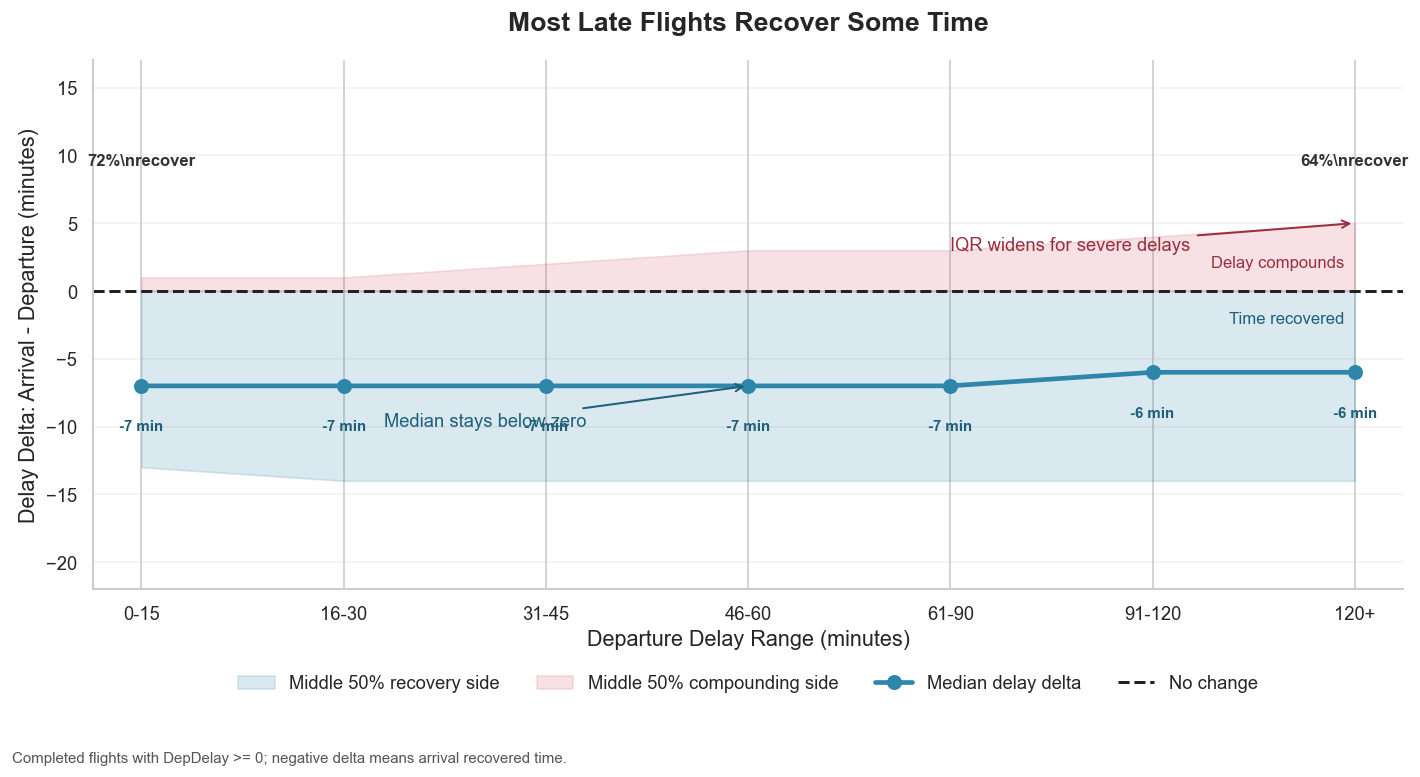

In [3]:
# Insight 1: Delay recovery by departure-delay range
v1_flights = df_active[df_active['DepDelay'] >= 0].copy()
dep_delay_bins = [0, 15, 30, 45, 60, 90, 120, np.inf]
dep_delay_labels = ['0-15', '16-30', '31-45', '46-60', '61-90', '91-120', '120+']
v1_flights['DepDelayRange'] = pd.cut(
    v1_flights['DepDelay'],
    bins=dep_delay_bins,
    labels=dep_delay_labels,
    include_lowest=True
)

v1_summary = (
    v1_flights.dropna(subset=['DepDelayRange'])
    .groupby('DepDelayRange', observed=True)
    .agg(
        median_delta=('DelayDelta', 'median'),
        q1_delta=('DelayDelta', lambda values: values.quantile(0.25)),
        q3_delta=('DelayDelta', lambda values: values.quantile(0.75)),
        recovered_share=('DelayDelta', lambda values: (values < 0).mean())
    )
    .reindex(dep_delay_labels)
    .reset_index()
)

x = np.arange(len(v1_summary))
median = v1_summary['median_delta']
iqr_lower = v1_summary['q1_delta']
iqr_upper = v1_summary['q3_delta']
y_min = min(iqr_lower.min(), median.min())
y_max = max(iqr_upper.max(), median.max())

fig, ax = plt.subplots(figsize=(12, 6.5))
ax.fill_between(
    x,
    iqr_lower,
    np.minimum(iqr_upper, 0),
    where=iqr_lower < 0,
    color='#2E86AB',
    alpha=0.18,
    label='Middle 50% recovery side',
)
ax.fill_between(
    x,
    np.maximum(iqr_lower, 0),
    iqr_upper,
    where=iqr_upper > 0,
    color='#D1495B',
    alpha=0.16,
    label='Middle 50% compounding side',
)
ax.plot(
    x,
    median,
    marker='o',
    color='#2E86AB',
    linewidth=2.8,
    markersize=8,
    label='Median delay delta',
)
ax.axhline(0, color='#222222', linestyle='--', linewidth=1.8, label='No change')
ax.set_xticks(x)
ax.set_xticklabels(v1_summary['DepDelayRange'].astype(str))
ax.set_title('Most Late Flights Recover Some Time', fontsize=16, fontweight='bold', pad=18)
ax.set_xlabel('Departure Delay Range (minutes)', fontsize=13)
ax.set_ylabel('Delay Delta: Arrival - Departure (minutes)', fontsize=13)
ax.set_ylim(y_min - 8, y_max + 12)
ax.grid(axis='y', alpha=0.25)
ax.margins(x=0.04)

for x_pos, row in zip(x, v1_summary.itertuples()):
    ax.text(x_pos, row.median_delta - 2.5, f'{row.median_delta:.0f} min',
            ha='center', va='top', fontsize=9, fontweight='bold', color='#1F5F7A')

for idx in [0, len(v1_summary) - 1]:
    row = v1_summary.iloc[idx]
    ax.text(x[idx], y_max + 4, f"{row['recovered_share']:.0%}\\nrecover",
            ha='center', va='bottom', fontsize=10, fontweight='bold', color='#333333')

ax.annotate(
    'Median stays below zero',
    xy=(x[3], median.iloc[3]),
    xytext=(1.2, y_min + 4),
    arrowprops=dict(arrowstyle='->', color='#1F5F7A', lw=1.2),
    fontsize=11,
    color='#1F5F7A'
)
ax.annotate(
    'IQR widens for severe delays',
    xy=(x[-1], iqr_upper.iloc[-1]),
    xytext=(x[-3], y_max - 2),
    arrowprops=dict(arrowstyle='->', color='#9A2F3D', lw=1.2),
    fontsize=11,
    color='#9A2F3D'
)
ax.text(x[-1] - 0.05, 1.5, 'Delay compounds', color='#9A2F3D', fontsize=10, ha='right', va='bottom')
ax.text(x[-1] - 0.05, -1.5, 'Time recovered', color='#1F5F7A', fontsize=10, ha='right', va='top')
ax.legend(frameon=False, loc='upper center', bbox_to_anchor=(0.5, -0.13), ncol=4)
fig.text(0.01, 0.01, 'Completed flights that departed on time or late; negative values mean the flight recovered time.',
         fontsize=9, color='#555555')
plt.tight_layout(rect=[0, 0.05, 1, 1])


The median delay delta stays below zero in every departure-delay range, so the typical late flight recovers some schedule time before arrival. The share of flights that recover declines as departure delay grows, and the interquartile range widens with more red area above zero, so severe late departures are less predictable even when median recovery remains negative.


## Insight 2: Late Aircraft and Carrier Delays Lead

**Question:** Which attributed delay causes contribute the most to completed-flight delay minutes?

**Answer:** **Late-arriving aircraft delays** (late inbound aircraft cascading into later departures) and **carrier-controlled operational delays** (crew scheduling, maintenance, and related airline operations) are the two largest contributors when averaged across completed flights. **National Airspace System delays** are also meaningful, so the story is not only airline-controlled; weather and security delays are much smaller in the annual completed-flight average.

This points to two major improvement paths: airline operational reliability through better turnaround, crew management, and planning, plus system-level airspace and airport-flow coordination.


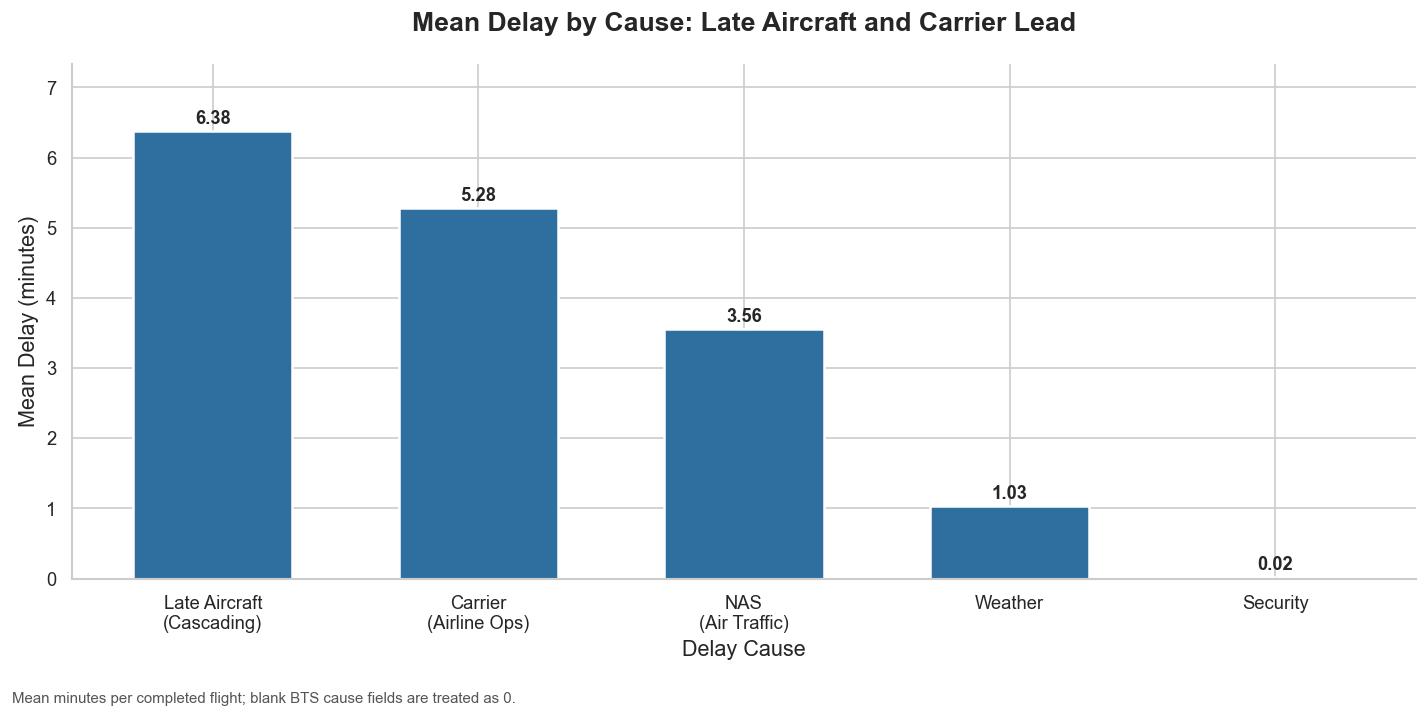

In [4]:
# Insight 2: Mean delay by cause
delay_causes = ['CarrierDelay', 'WeatherDelay', 'NASDelay', 'SecurityDelay', 'LateAircraftDelay']
cause_labels = {
    'CarrierDelay': 'Carrier\n(Airline Ops)',
    'WeatherDelay': 'Weather',
    'NASDelay': 'NAS\n(Air Traffic)',
    'SecurityDelay': 'Security',
    'LateAircraftDelay': 'Late Aircraft\n(Cascading)'
}
cause_means = df_active[delay_causes].mean().sort_values(ascending=False)
cause_label_order = [cause_labels[cause] for cause in cause_means.index]

fig, ax = plt.subplots(figsize=(12, 6))
colors = '#2F6F9F'
bars = ax.bar(cause_label_order, cause_means.values, color=colors, edgecolor='white', linewidth=1.5, width=0.6)
ax.set_title('Mean Delay by Cause: Late Aircraft and Carrier Lead', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Delay Cause', fontsize=13)
ax.set_ylabel('Mean Delay (minutes)', fontsize=13)
for bar, val in zip(bars, cause_means.values):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.05,
            f'{val:.2f}', ha='center', va='bottom', fontweight='bold', fontsize=11)
ax.set_ylim(0, cause_means.max() * 1.15)
fig.text(0.01, 0.01, 'Mean minutes per completed flight; blank BTS cause fields are treated as 0.',
         fontsize=9, color='#555555')
plt.tight_layout(rect=[0, 0.04, 1, 1])


The sorted bar chart shows that late-arriving aircraft delays and carrier-controlled operational delays are the two largest attributed causes when averaged across completed flights, with National Airspace System delays still meaningful. Late-arriving aircraft delay reflects cascading schedule effects: a late arrival at one airport can delay the aircraft's next departure. Carrier-controlled delay covers crew scheduling, maintenance, and other airline-controlled factors, while National Airspace System delay captures airspace and airport-flow constraints. Weather and security are much smaller in this annual completed-flight average, so the strongest levers are airline operational reliability plus airspace and airport coordination.


## Insight 3: Sunday Evening Is the Highest-Risk Window

**Question:** Are certain days and departure times associated with more significant arrival delays?

**Answer:** Yes, delay risk rises through the day and peaks on **Sunday evening**. Tuesday is consistently lower-risk, while Thursday and Friday evenings are also elevated but do not exceed Sunday evening.

For travelers, timing matters: morning departures and Tuesday flights generally carry lower risk than late-day Sunday departures.


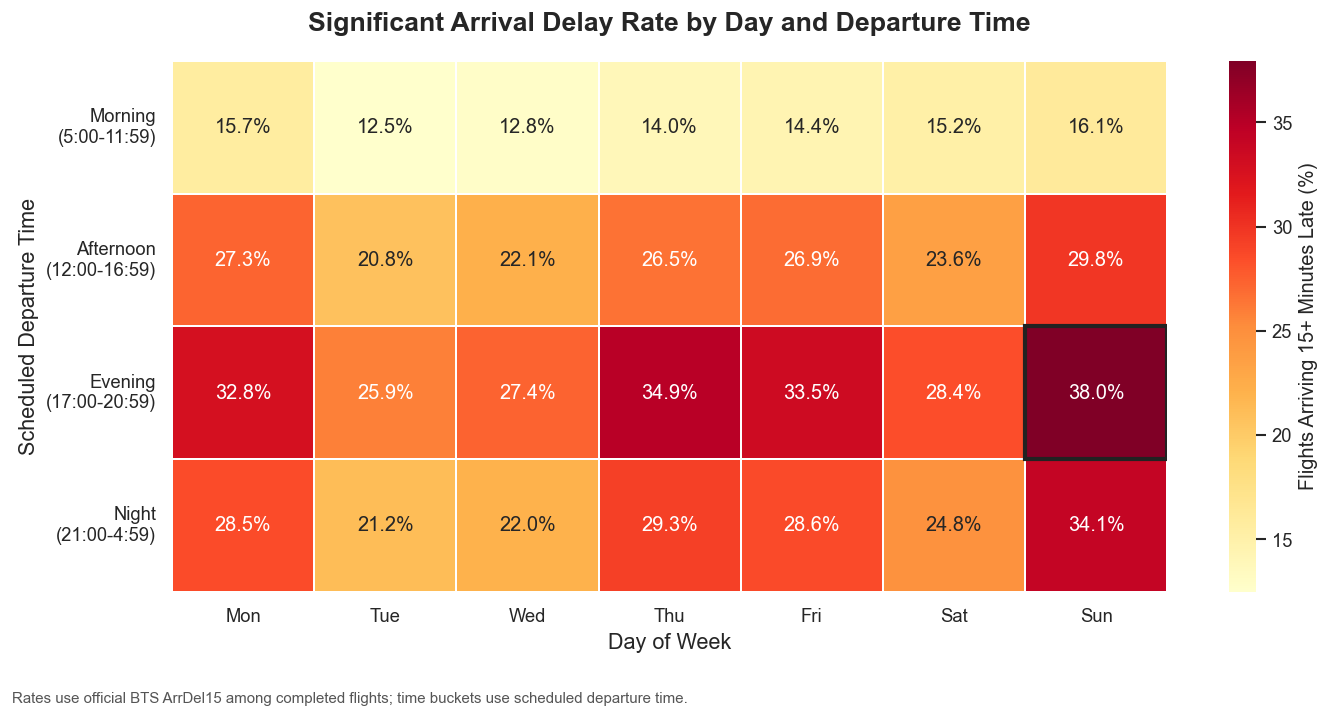

In [5]:
# Insight 3: Significant arrival delay rate by day and scheduled departure time
time_order = ['Morning', 'Afternoon', 'Evening', 'Night']
time_labels = {
    'Morning': 'Morning\n(5:00-11:59)',
    'Afternoon': 'Afternoon\n(12:00-16:59)',
    'Evening': 'Evening\n(17:00-20:59)',
    'Night': 'Night\n(21:00-4:59)'
}
day_order = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

arr_delay_by_day_time = (
    df_active.dropna(subset=['ArrDel15', 'DayName', 'TimeOfDay'])
    .groupby(['TimeOfDay', 'DayName'])['ArrDel15']
    .agg(delay_rate='mean', flights='count')
)
arr_delay_by_day_time['delay_rate'] = arr_delay_by_day_time['delay_rate'] * 100

delay_heatmap = (
    arr_delay_by_day_time['delay_rate']
    .unstack('DayName')
    .reindex(index=time_order, columns=day_order)
)
annot = delay_heatmap.round(1).astype(str) + '%'

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(
    delay_heatmap,
    annot=annot,
    fmt='',
    cmap='YlOrRd',
    linewidths=1,
    linecolor='white',
    cbar_kws={'label': 'Flights Arriving 15+ Minutes Late (%)'},
    ax=ax
)

max_time, max_day = delay_heatmap.stack().idxmax()
max_row = time_order.index(max_time)
max_col = day_order.index(max_day)
ax.add_patch(plt.Rectangle((max_col, max_row), 1, 1, fill=False, edgecolor='#222222', lw=2.5))
ax.set_title('Significant Arrival Delay Rate by Day and Departure Time', fontsize=16, fontweight='bold', pad=18)
ax.set_xlabel('Day of Week', fontsize=13)
ax.set_ylabel('Scheduled Departure Time', fontsize=13)
ax.tick_params(axis='x', rotation=0)
ax.set_yticklabels([time_labels[label] for label in time_order], rotation=0)
fig.text(0.01, 0.01, 'Rates use official BTS ArrDel15 among completed flights; time buckets use scheduled departure time.',
         fontsize=9, color='#555555')
plt.tight_layout(rect=[0, 0.05, 1, 1])


The highest cell is Sunday evening at 38.0% of flights arriving 15 or more minutes late. Delay risk increases from morning to evening across the week, Tuesday remains comparatively low, and Friday evening is elevated but not the overall peak.


## Insight 4: Seasonality Peaks in Summer and December

**Question:** Are there seasonal patterns in significant arrival delays?

**Answer:** Yes, the strongest delay rates occur in **June and July**, followed by a separate **December** spike. September is the clearest low-delay month. This is more specific than a broad winter-versus-summer story: the 2025 data shows a pronounced summer peak and a holiday/weather spike in December.


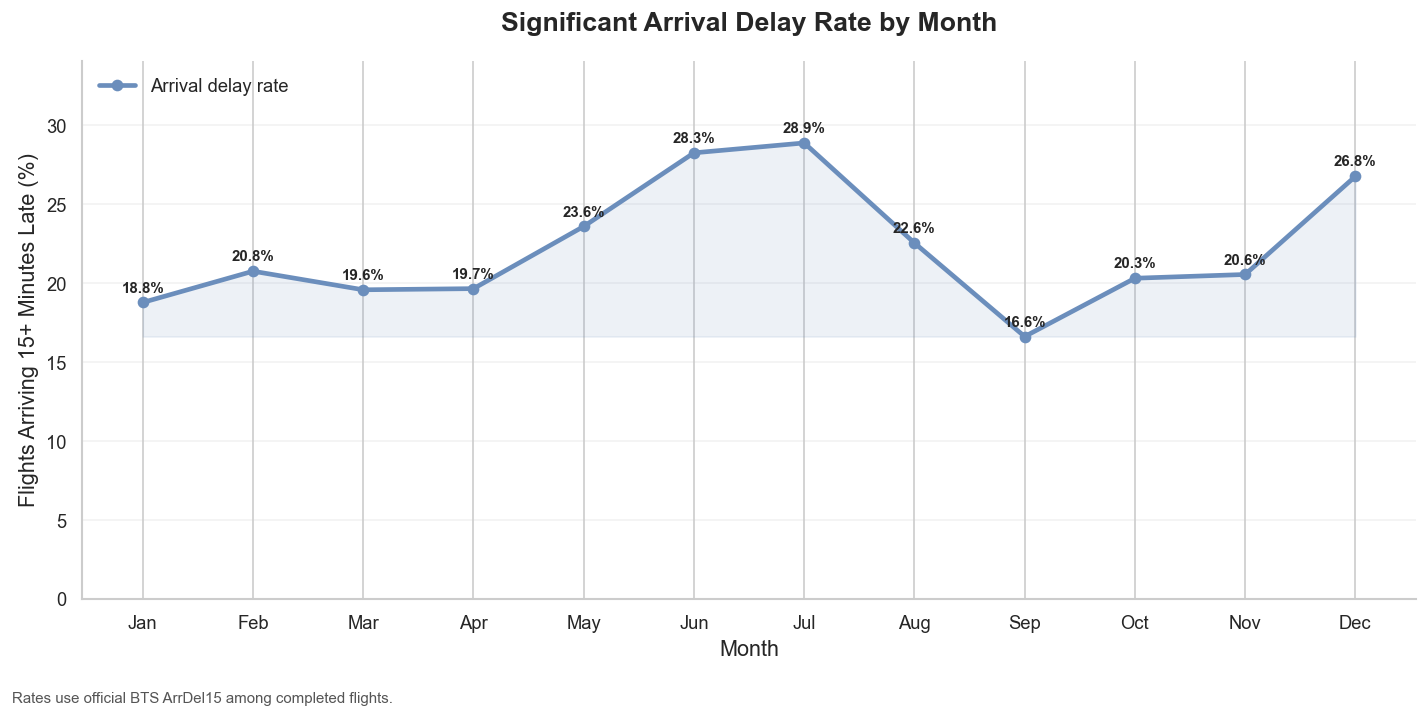

In [6]:
# Insight 4: Significant arrival delay rate by month
month_names = {
    1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr',
    5: 'May', 6: 'Jun', 7: 'Jul', 8: 'Aug',
    9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'
}

arr_del15_by_month = (
    df_active.dropna(subset=['ArrDel15'])
    .groupby('Month')['ArrDel15']
    .agg(delay_rate='mean', flights='count')
    .reindex(range(1, 13))
)
arr_del15_by_month['delay_rate'] = arr_del15_by_month['delay_rate'] * 100

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(
    arr_del15_by_month.index,
    arr_del15_by_month['delay_rate'],
    marker='o',
    linewidth=2.8,
    color='#6B8EBC',
    label='Arrival delay rate'
)
ax.fill_between(
    arr_del15_by_month.index,
    arr_del15_by_month['delay_rate'],
    arr_del15_by_month['delay_rate'].min(),
    color='#6B8EBC',
    alpha=0.12
)
for month, pct in arr_del15_by_month['delay_rate'].items():
    ax.text(month, pct + 0.45, f'{pct:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_title('Significant Arrival Delay Rate by Month', fontsize=16, fontweight='bold', pad=18)
ax.set_xlabel('Month', fontsize=13)
ax.set_ylabel('Flights Arriving 15+ Minutes Late (%)', fontsize=13)
ax.set_xticks(range(1, 13))
ax.set_xticklabels([month_names[m] for m in range(1, 13)])
ax.set_ylim(0, arr_del15_by_month['delay_rate'].max() * 1.18)
ax.grid(axis='y', alpha=0.25)
ax.legend(frameon=False, loc='upper left')
fig.text(0.01, 0.01, 'Rates use official BTS ArrDel15 among completed flights.', fontsize=9, color='#555555')
plt.tight_layout(rect=[0, 0.04, 1, 1])


June and July have the highest significant arrival-delay rates, December is the strongest winter/holiday spike, and September is the lowest month. The pattern supports targeted seasonal planning rather than treating all winter months or all summer months as equally risky.


## Insight 5: Geography Matters, but State/Territory Aggregation Is Coarse

**Question:** Do some origins show larger departure-to-arrival recovery gaps than others?

**Answer:** Yes, origin states and territories differ in how much delay changes between departure and arrival. However, the largest gaps are mostly recovery gaps, meaning average arrival delay is lower than average departure delay. This view is a recovery-gap screen rather than a ranking of the worst-delay states. State-level aggregation is useful for screening geographic patterns, but airport- or route-level analysis would be needed for operational decisions.


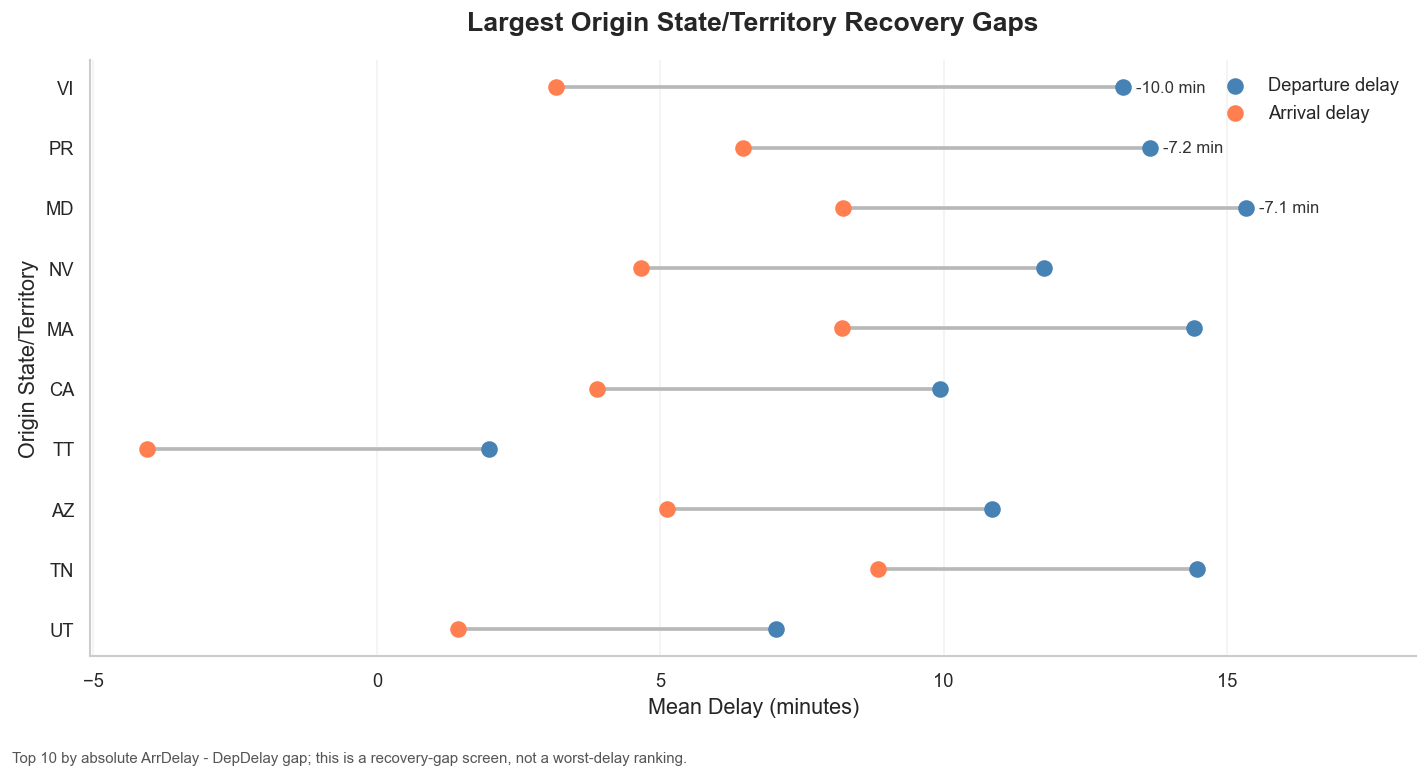

In [7]:
# Insight 5: Departure vs arrival delay by origin state/territory
state_delays = df_active.groupby('OriginState').agg({
    'DepDelay': 'mean',
    'ArrDelay': 'mean'
})
state_delays['DelayDelta'] = state_delays['ArrDelay'] - state_delays['DepDelay']

top_states = state_delays['DelayDelta'].abs().sort_values(ascending=False).head(10).index
state_delays = state_delays.loc[top_states].sort_values(
    'DelayDelta', key=lambda values: values.abs(), ascending=False
)

fig, ax = plt.subplots(figsize=(12, 6.5))
y = np.arange(len(state_delays))
ax.hlines(
    y=y,
    xmin=state_delays['DepDelay'],
    xmax=state_delays['ArrDelay'],
    color='#B8B8B8',
    linewidth=2.2,
    zorder=1
)
ax.scatter(state_delays['DepDelay'], y, color='steelblue', s=80, label='Departure delay', zorder=2)
ax.scatter(state_delays['ArrDelay'], y, color='coral', s=80, label='Arrival delay', zorder=3)

for state in state_delays.index[:3]:
    row = state_delays.loc[state]
    y_pos = state_delays.index.get_loc(state)
    x_pos = max(row['DepDelay'], row['ArrDelay'])
    ax.annotate(
        f"{row['DelayDelta']:+.1f} min",
        xy=(x_pos, y_pos),
        xytext=(8, 0),
        textcoords='offset points',
        va='center',
        fontsize=10,
        color='#333333'
    )

x_min = state_delays[['DepDelay', 'ArrDelay']].min().min()
x_max = state_delays[['DepDelay', 'ArrDelay']].max().max()
ax.set_xlim(min(0, x_min - 1), x_max + 3)
ax.set_yticks(y)
ax.set_yticklabels(state_delays.index)
ax.invert_yaxis()
ax.set_title('Largest Origin State/Territory Recovery Gaps', fontsize=16, fontweight='bold', pad=18)
ax.set_xlabel('Mean Delay (minutes)', fontsize=13)
ax.set_ylabel('Origin State/Territory', fontsize=13)
ax.grid(axis='x', alpha=0.25)
ax.grid(axis='y', visible=False)
ax.legend(frameon=False, loc='upper right')
fig.text(0.01, 0.01, 'Top 10 by absolute average arrival-vs-departure delay gap; this is a recovery-gap screen, not a worst-delay ranking.',
         fontsize=9, color='#555555')
plt.tight_layout(rect=[0, 0.04, 1, 1])


The largest origin-level gaps in the 2025 data are recovery gaps: mean arrival delay is lower than mean departure delay for the highlighted states and territories. Because the chart is filtered to the largest absolute gaps, it should not be read as a complete ranking of worst-delay states. This supports the Part I conclusion that geography matters, while also showing why state-level aggregation should be treated as a coarse screening view rather than a final hub-level diagnosis.


## Summary and Key Takeaways

**Five insights from 7,001,619 scheduled flights:**

1. **Flights often recover time**: completed flights usually make up delay minutes after departure
2. **Late aircraft and carrier-controlled delays lead**: they are the largest attributed contributors, with airspace/airport-flow delay also meaningful
3. **Sunday evening is highest risk**: delay risk rises through the day, with Thursday and Friday evenings also elevated
4. **Seasonality peaks in summer and December**: June/July lead the year, September is lowest, and December is the main winter spike
5. **Geography matters, but coarsely**: origin states and territories show different recovery gaps, but airport and route context would be needed for decisions

**Bottom line:** Departure delay remains the strongest signal for arrival delay, but completed flights often make up some delay minutes en route. The clearest levers for reducing delay risk are airline operational reliability, airspace/airport coordination, and schedule planning around high-risk time windows and seasons.

**For travelers:** Choose morning departures when possible, treat Sunday evening as the riskiest window, and be especially cautious during the June/July summer peak and December holiday/weather spike.


## Export

To generate the HTML slide deck:

```bash
jupyter nbconvert Part_II_explanatory.ipynb --to slides --no-input --no-prompt
```
